augumented

In [5]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# import os
# import random
# from PIL import Image, ImageEnhance

# input_folder = r"C:\Users\HP\Documents\Land Slide"
# output_folder = r"C:\Users\HP\Documents\Mini2_Final\Project\Images_Data\Land Slide"
# target_count = 900

# os.makedirs(output_folder, exist_ok=True)

# # Load all images
# image_files = [f for f in os.listdir(input_folder)
#             if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"))]

# print(f"Found {len(image_files)} original images")

# # First, copy originals to output folder
# for f in image_files:
#     img = Image.open(os.path.join(input_folder, f))
#     img.save(os.path.join(output_folder, f))

# current_count = len(image_files)
# aug_index = 1

# # Augmentation functions
# def augment_image(img):
#     choice = random.choice(["rotate", "flip", "brightness", "contrast", "zoom"])

#     if choice == "rotate":
#         angle = random.uniform(-20, 20)
#         return img.rotate(angle)

#     elif choice == "flip":
#         return img.transpose(Image.FLIP_LEFT_RIGHT)

#     elif choice == "brightness":
#         enhancer = ImageEnhance.Brightness(img)
#         factor = random.uniform(0.7, 1.3)
#         return enhancer.enhance(factor)

#     elif choice == "contrast":
#         enhancer = ImageEnhance.Contrast(img)
#         factor = random.uniform(0.7, 1.3)
#         return enhancer.enhance(factor)

#     elif choice == "zoom":
#         w, h = img.size
#         crop_ratio = random.uniform(0.85, 0.95)
#         new_w, new_h = int(w * crop_ratio), int(h * crop_ratio)
#         left = (w - new_w) // 2
#         top = (h - new_h) // 2
#         right = left + new_w
#         bottom = top + new_h
#         cropped = img.crop((left, top, right, bottom))
#         return cropped.resize((w, h), Image.LANCZOS)

# # Generate new images
# while current_count < target_count:
#     filename = random.choice(image_files)
#     img_path = os.path.join(input_folder, filename)

#     with Image.open(img_path) as img:
#         aug_img = augment_image(img)
#         new_name = f"aug_{aug_index}_{filename}"
#         aug_img.save(os.path.join(output_folder, new_name))

#     aug_index += 1
#     current_count += 1

# print(f"Done! Total images: {current_count}")
# print(f"Saved in: {output_folder}")


Found 456 original images
Done! Total images: 900
Saved in: C:\Users\HP\Documents\Mini2_Final\Project\Images_Data\Land Slide


Dataset class distribution

In [7]:
import os

DATASET_DIR = r"C:\Users\HP\Documents\Major_Final\Github-code\Module-2_Mini-2\Images_Data

class_counts = {}

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        class_counts[class_name] = len(images)

print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class Distribution:
Cyclone: 928
Earthquake: 1386
Flood: 1617
Infrastructure: 1028
Land Slide: 900
Non Damage: 1126
Urban Fire: 1069
Wild Fire: 1591


Class distribution Plot

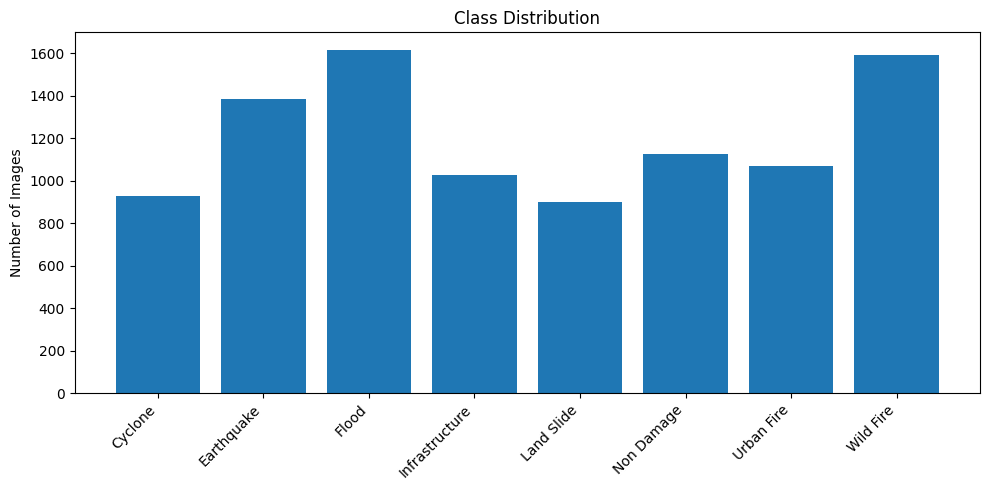

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


MOBILENETV2

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ---------------- CONFIG ----------------
DATASET_DIR = r"C:\Users\HP\Documents\Mini2_Final\Project\Images_Data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-5
# --------------------------------------

# ---------------- DATA ----------------
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
).flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# ---------------- CLASS WEIGHTS ----------------
y_train = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(enumerate(class_weights))

# ---------------- MODEL ----------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# TRUE fine-tuning
for layer in base_model.layers:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

model = Model(base_model.input, output)

model.compile(
    optimizer=Adam(LR),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight
)

# ---------------- EVALUATION ----------------
val_gen.reset()
y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes

print(classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys()))


Found 7719 images belonging to 8 classes.
Found 1926 images belonging to 8 classes.


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 1022s 4s/step - accuracy: 0.3385 - loss: 1.8632 - val_accuracy: 0.4746 - val_loss: 1.5398
Epoch 2/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 970s 4s/step - accuracy: 0.6097 - loss: 1.3446 - val_accuracy: 0.5685 - val_loss: 1.3582
Epoch 3/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 1050s 4s/step - accuracy: 0.7062 - loss: 1.1509 - val_accuracy: 0.6604 - val_loss: 1.2209
Epoch 4/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 1011s 4s/step - accuracy: 0.7404 - loss: 1.0675 - val_accuracy: 0.7238 - val_loss: 1.0969
Epoch 5/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 933s 4s/step - accuracy: 0.7659 - loss: 1.0200 - val_accuracy: 0.7648 - val_loss: 1.0153
Epoch 6/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 896s 4s/step - accuracy: 0.7939 - loss: 0.9625 - val_accuracy: 0.7825 - val_loss: 0.9769
Epoch 7/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 896s 4s/step - accuracy: 0.8146 - loss: 0.9308 - val_accuracy: 0.7991 - val_loss: 0.9501
Epoch 8/25
242/242 ━━━━━━━━━━━━━━━━━━━━ 925s 4s/step - accuracy: 0.8242 - loss: 0.9080 - val_a

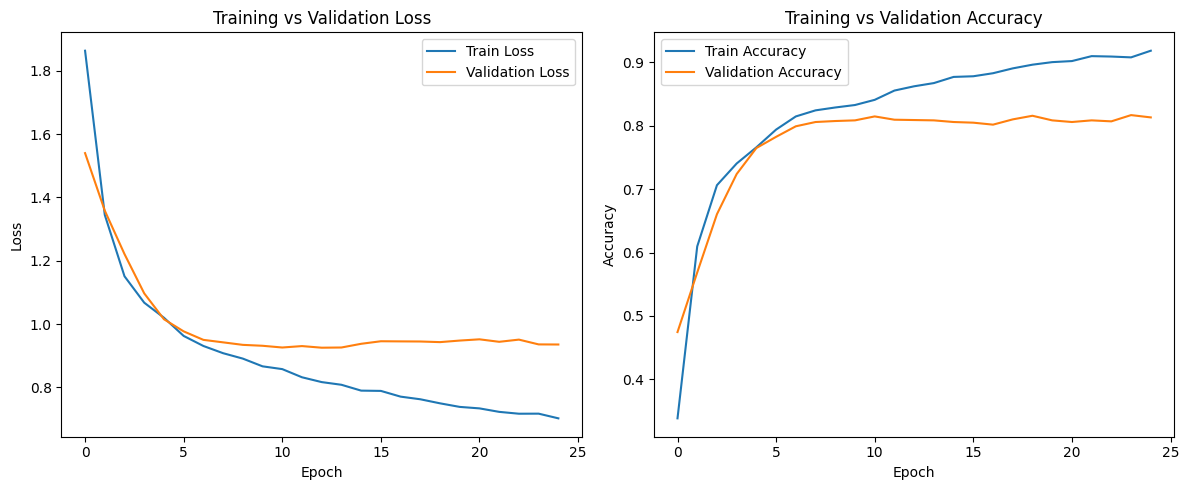

In [10]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(history)


In [11]:
import numpy as np

val_gen.reset()
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_gen.class_indices.keys())


61/61 ━━━━━━━━━━━━━━━━━━━━ 43s 690ms/step


In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


                precision    recall  f1-score   support

       Cyclone     1.0000    0.9892    0.9946       185
    Earthquake     0.8370    0.5560    0.6681       277
         Flood     0.9142    0.7585    0.8291       323
Infrastructure     0.5148    0.9317    0.6632       205
    Land Slide     0.7033    0.8167    0.7558       180
    Non Damage     1.0000    0.7600    0.8636       225
    Urban Fire     0.7778    0.9859    0.8696       213
     Wild Fire     0.9815    0.8333    0.9014       318

      accuracy                         0.8131      1926
     macro avg     0.8411    0.8289    0.8182      1926
  weighted avg     0.8552    0.8131    0.8178      1926



<Figure size 1000x1000 with 0 Axes>

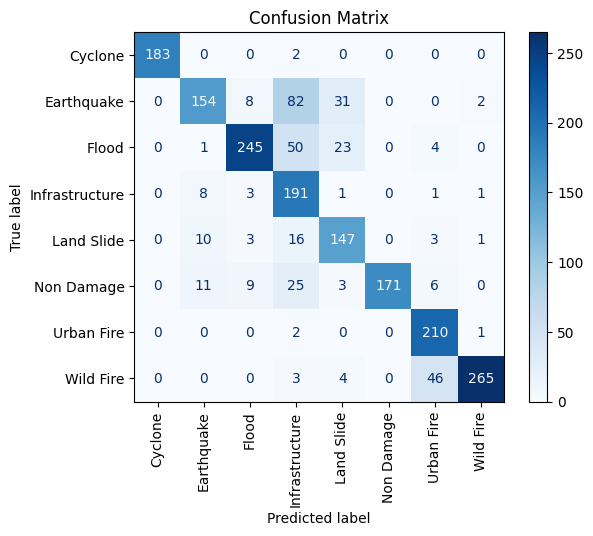

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall    = recall_score(y_true, y_pred, average="macro")
f1        = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1-score : {f1:.4f}")


Accuracy       : 0.8131
Macro Precision: 0.8411
Macro Recall   : 0.8289
Macro F1-score : 0.8182


In [15]:
model.save("mobilenetv2_finetuned.h5")
